# aule — Ensemble & Uncertainty metrics

This notebook covers `aule.metrics.ensemble` and `aule.metrics.uncertainty`: metrics for **probabilistic forecasts**, where instead of a single prediction we have an ensemble of `n_members` plausible predictions.

The ensemble convention in aule: an array of shape `(n_members, *single_member_shape)`, where `single_member_shape` follows the usual 4 aule shapes, and the ground truth has no ensemble axis.

In [ ]:
!pip install aule

## Setup

We simulate a ground truth field and a 20-member ensemble forecast (e.g. from an ensemble weather/climate model) with realistic spread around the truth.

In [1]:
import numpy as np

np.random.seed(2)

gt = np.random.rand(64, 64, 1)

n_members = 20
ensemble = gt[np.newaxis] + np.random.normal(0, 0.1, (n_members, 64, 64, 1))

print('gt shape:      ', gt.shape)
print('ensemble shape:', ensemble.shape)

gt shape:       (64, 64, 1)
ensemble shape: (20, 64, 64, 1)


## Ensemble spread

`ensemble_spread` is simply the standard deviation across members, averaged over space — a measure of forecast uncertainty, independent of how close the ensemble is to the truth.

In [2]:
from aule.metrics import ensemble_spread

print('Ensemble spread:', ensemble_spread(ensemble))

Ensemble spread: 0.0963404474757871


## CRPS (Continuous Ranked Probability Score)

CRPS is the most common scalar metric for evaluating a full ensemble/probabilistic forecast against a single observation. Lower is better; 0 means a perfect deterministic forecast.

In [3]:
from aule.metrics import crps

score = crps(gt, ensemble)
print('CRPS:', score)

# sanity check: a perfect deterministic "ensemble" (all members equal to gt) should give CRPS ~ 0
perfect_ensemble = np.stack([gt] * n_members, axis=0)
print('CRPS (perfect ensemble):', crps(gt, perfect_ensemble))

CRPS: 0.02618147573452042
CRPS (perfect ensemble): 0.0


## Rank histogram (Talagrand diagram)

For each pixel, we find the rank of the true value among the sorted ensemble members. A well-calibrated ensemble has a roughly *flat* rank histogram; U-shaped means the ensemble is under-dispersive (too narrow), dome-shaped means over-dispersive (too wide).

In [4]:
from aule.metrics import rank_histogram

counts = rank_histogram(gt, ensemble)
print('Rank histogram counts (length = n_members + 1 = {}):'.format(n_members + 1))
print(counts)

Rank histogram counts (length = n_members + 1 = 21):
[  0   0   1   4  20  57 136 325 487 630 720 651 494 326 150  72  18   4
   1   0   0]


## Brier score (binary event probability)

If we care about a binary event (e.g. "value exceeds a threshold"), `brier_score` treats the fraction of ensemble members exceeding the threshold as the forecast probability, then scores it against the observed binary outcome.

In [5]:
from aule.metrics import brier_score

threshold = 0.6
score = brier_score(gt, ensemble, threshold=threshold)
print(f'Brier score (threshold={threshold}):', score)

Brier score (threshold=0.6): 0.026356811523437502


## Spread-skill ratio

A core calibration diagnostic: the ratio between ensemble spread and the RMSE of the ensemble mean. A value close to 1 means the ensemble's stated uncertainty matches its actual error; well below 1 means overconfidence (under-dispersion); well above 1 means underconfidence (over-dispersion).

In [6]:
from aule.metrics import spread_skill_ratio

ratio = spread_skill_ratio(gt, ensemble)
print('Spread-skill ratio:', ratio, '(close to 1 = well calibrated)')

Spread-skill ratio: 4.28693128548753 (close to 1 = well calibrated)


## CRPS skill score (relative to a reference/baseline)

Often we want to know if a forecast improves on a baseline (e.g. climatology, or a simpler model), not just its absolute CRPS. `crps_skill_score` gives a relative improvement score: positive means better than the reference, 0 means equal, negative means worse.

In [7]:
from aule.metrics import crps_skill_score

reference_ensemble = gt[np.newaxis] + np.random.normal(0, 0.3, (n_members, 64, 64, 1))  # a much worse baseline

score = crps_skill_score(gt, ensemble, reference_ensemble)
print('CRPS skill score (vs. worse baseline):', score, '(positive = improvement)')

CRPS skill score (vs. worse baseline): 0.6642545946696063 (positive = improvement)


## Uncertainty calibration: PICP

`picp` (Prediction Interval Coverage Probability) checks whether a nominal confidence interval (e.g. 90%) derived from the ensemble actually contains the observed truth that often.

In [8]:
from aule.metrics import picp

coverage = picp(gt, ensemble, confidence=0.9)
print('PICP (nominal 90% interval):', coverage, '(should be close to 0.9 for a well-calibrated ensemble)')

PICP (nominal 90% interval): 1.0 (should be close to 0.9 for a well-calibrated ensemble)


## Uncertainty calibration: PIT histogram

`pit_histogram` is the continuous-CDF analogue of the rank histogram: for each observation, we compute where it falls in the ensemble's empirical CDF, then histogram those values. A flat PIT histogram indicates good calibration.

In [9]:
from aule.metrics import pit_histogram

counts = pit_histogram(gt, ensemble, n_bins=10)
print('PIT histogram counts:', counts)

PIT histogram counts: [   0   11  104  613 1281 1354  594  130    9    0]


## Visualizing the rank histogram

Let's plot the rank histogram counts directly with matplotlib for a quick visual calibration check (the dedicated `aule.plots.plot_rank_histogram` function is shown in the plotting notebook).

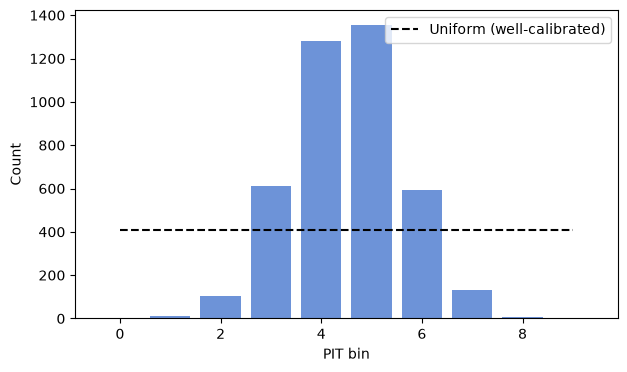

In [10]:
import matplotlib.pyplot as plt

ranks = np.arange(len(counts))
expected = np.full(len(counts), counts.sum() / len(counts))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ranks, counts, color='#4878CF', alpha=0.8)
ax.plot(ranks, expected, 'k--', label='Uniform (well-calibrated)')
ax.set_xlabel('PIT bin')
ax.set_ylabel('Count')
ax.legend()
plt.show()